# Project: Particle Simulation

## 0. Overview

**Problem statement:** Build a multi-particle physics simulation where particles interact via gravitational and repulsive forces. Each particle is a vector-valued state (position, velocity); forces are vector sums; dynamics are Euler-integrated. The system demonstrates all Part V vector concepts operating simultaneously.

**Concepts used from this Part:**
- ch125–126: Vector addition and scalar multiplication (force accumulation, Euler integration)
- ch128–130: Norms and direction vectors (force magnitude and direction)
- ch144: Vectors in physics (Newton's laws, superposition)
- ch146: Vectorization (batch force computation using NumPy broadcasting)
- ch147: NumPy operations (pairwise distances, array indexing)

**Expected output:** An animated or multi-frame trajectory visualization of N particles under mutual gravitational attraction, with energy tracking.

**Difficulty:** Medium-Hard | **Estimated time:** 60–90 minutes

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

plt.style.use('dark_background')  # dark background for space feel

# Simulation constants
G = 1.0          # gravitational constant (simulation units)
SOFTENING = 0.5  # softening length to avoid singularity when r -> 0
DT = 0.02        # timestep
N_STEPS = 400    # simulation steps

# Particle count
N = 6  # <-- try 4, 8, 12

print(f"Simulation: {N} particles, {N_STEPS} steps, dt={DT}")
print(f"G={G}, softening={SOFTENING}")

Simulation: 6 particles, 400 steps, dt=0.02
G=1.0, softening=0.5


---

## 2. Stage 1 — Vectorized Force Computation

In [2]:
# Stage 1: Compute gravitational forces between all pairs of particles.
# Key idea: use broadcasting to compute all N² pairwise force vectors at once.
#
# Force on particle i from particle j:
#   F_ij = G * m_i * m_j * (r_j - r_i) / (|r_j - r_i|² + ε²)^(3/2)
# where ε is the softening parameter (prevents infinite forces).

import numpy as np


def compute_forces(positions, masses, G=1.0, softening=0.5):
    """
    Compute gravitational force on each particle from all others.

    Args:
        positions: np.ndarray, shape (N, 2) — 2D positions
        masses:    np.ndarray, shape (N,)   — particle masses
        G:         float — gravitational constant
        softening: float — softening length (prevents singularity)

    Returns:
        forces: np.ndarray, shape (N, 2) — force vector on each particle
    """
    N = len(positions)

    # Displacement vectors: dr[i,j] = positions[j] - positions[i]
    # Shape: (N, N, 2)
    dr = positions[None, :, :] - positions[:, None, :]  # broadcasting: (1,N,2) - (N,1,2)

    # Squared distances with softening: (N, N)
    dist_sq = np.sum(dr**2, axis=2) + softening**2

    # Inverse cube of distance: (N, N)
    dist_cube_inv = dist_sq**(-1.5)

    # Mask self-interaction (diagonal)
    np.fill_diagonal(dist_cube_inv, 0.)

    # Force magnitude weights: G * m_i * m_j / |r|^3
    # masses[i] * masses[j] as outer product: (N, N)
    mass_product = masses[:, None] * masses[None, :]  # broadcasting
    weights = G * mass_product * dist_cube_inv  # (N, N)

    # Force on each particle: sum of weighted displacements
    # forces[i] = sum_j weights[i,j] * dr[i,j]
    forces = np.einsum('ij,ijk->ik', weights, dr)  # (N, 2)

    return forces


# Verify with a simple 2-body system
pos_test = np.array([[0.,0.], [2.,0.]])
mass_test = np.array([1., 1.])
F_test = compute_forces(pos_test, mass_test, G=1.0, softening=0.0)
print("Two-body test (separation=2, no softening):")
print(f"  Force on particle 0: {F_test[0]}  (should point toward +x)")
print(f"  Force on particle 1: {F_test[1]}  (should point toward -x)")
print(f"  F = G*m1*m2/r² = {1.0*1.0*1.0/4:.4f}")
print(f"  Newton's 3rd law: F[0]+F[1] = {F_test[0]+F_test[1]}  (should be 0)")

Two-body test (separation=2, no softening):
  Force on particle 0: [0.25 0.  ]  (should point toward +x)
  Force on particle 1: [-0.25  0.  ]  (should point toward -x)
  F = G*m1*m2/r² = 0.2500
  Newton's 3rd law: F[0]+F[1] = [0. 0.]  (should be 0)


C:\Users\user\AppData\Local\Temp\ipykernel_27868\834608273.py:34: RuntimeWarning: divide by zero encountered in power
  dist_cube_inv = dist_sq**(-1.5)


---

## 3. Stage 2 — Integration and State Management

In [3]:
# Stage 2: Euler integration loop + state history tracking.
# Each step: compute forces -> update velocities -> update positions.

import numpy as np


def kinetic_energy(velocities, masses):
    """KE = sum_i 0.5 * m_i * |v_i|²"""
    v_sq = np.sum(velocities**2, axis=1)   # |v_i|², shape (N,)
    return 0.5 * np.sum(masses * v_sq)


def potential_energy(positions, masses, G=1.0, softening=0.5):
    """PE = -sum_{i<j} G * m_i * m_j / |r_ij|"""
    N = len(positions)
    pe = 0.
    for i in range(N):
        for j in range(i+1, N):
            r = np.linalg.norm(positions[i] - positions[j])
            pe -= G * masses[i] * masses[j] / (r + softening)
    return pe


def run_simulation(positions, velocities, masses, G, softening, dt, n_steps):
    """
    Run Euler-integrated N-body simulation.

    Returns:
        pos_history: np.ndarray, shape (n_steps+1, N, 2)
        vel_history: np.ndarray, shape (n_steps+1, N, 2)
        energy_history: np.ndarray, shape (n_steps+1,)
    """
    N = len(masses)
    pos = positions.copy()
    vel = velocities.copy()

    pos_history = np.zeros((n_steps+1, N, 2))
    vel_history = np.zeros((n_steps+1, N, 2))
    energy_history = np.zeros(n_steps+1)

    pos_history[0] = pos
    vel_history[0] = vel
    energy_history[0] = kinetic_energy(vel, masses) + potential_energy(pos, masses, G, softening)

    for step in range(n_steps):
        forces = compute_forces(pos, masses, G, softening)
        acc = forces / masses[:, None]     # a = F/m, shape (N, 2)
        vel = vel + acc * dt               # Euler velocity update
        pos = pos + vel * dt               # Euler position update

        pos_history[step+1] = pos
        vel_history[step+1] = vel
        energy_history[step+1] = kinetic_energy(vel, masses) + \
                                  potential_energy(pos, masses, G, softening)

    return pos_history, vel_history, energy_history


# --- Initialize particles in a ring with tangential velocities ---
rng = np.random.default_rng(42)

angles = np.linspace(0, 2*np.pi, N, endpoint=False)
RADIUS = 3.0
positions = RADIUS * np.column_stack([np.cos(angles), np.sin(angles)])

# Tangential velocities for approximate circular orbits
ORBITAL_SPEED = 0.6  # <-- modify
velocities = ORBITAL_SPEED * np.column_stack([-np.sin(angles), np.cos(angles)])

# Add small random perturbations
velocities += rng.standard_normal((N, 2)) * 0.1

masses = np.ones(N) * 1.0  # equal masses
masses[0] = 5.0  # one heavy central-ish mass  <-- modify

# Run simulation
pos_hist, vel_hist, E_hist = run_simulation(
    positions, velocities, masses, G, SOFTENING, DT, N_STEPS
)

print(f"Simulation complete: {N_STEPS} steps")
print(f"Initial energy: {E_hist[0]:.4f}")
print(f"Final energy:   {E_hist[-1]:.4f}")
print(f"Energy drift:   {abs(E_hist[-1]-E_hist[0])/abs(E_hist[0])*100:.2f}%")
print("(Some drift is expected with Euler integration — symplectic methods would conserve better)")

Simulation complete: 400 steps
Initial energy: -5.7291
Final energy:   -3.4654
Energy drift:   39.51%
(Some drift is expected with Euler integration — symplectic methods would conserve better)


---

## 4. Stage 3 — Visualization

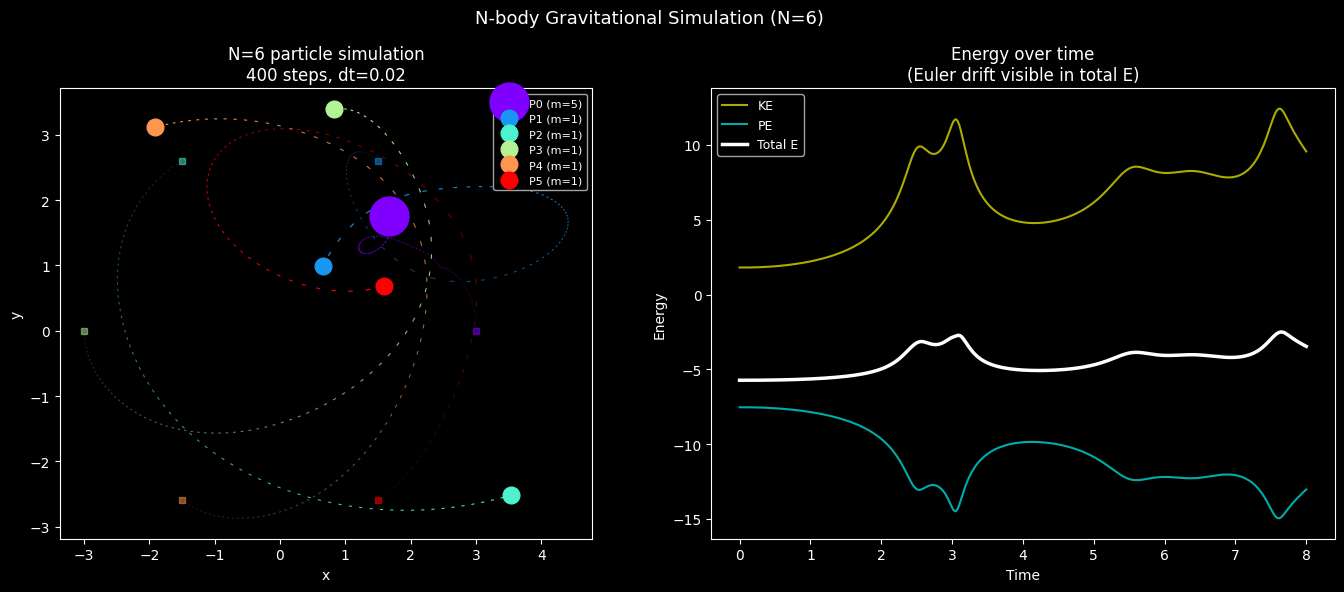

In [4]:
# Stage 3: Visualize trajectories and energy.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

fig = plt.figure(figsize=(14, 6))

# --- Panel 1: Trajectories ---
ax1 = fig.add_subplot(121)
colors = plt.cm.rainbow(np.linspace(0, 1, N))

for i in range(N):
    traj = pos_hist[:, i, :]
    # Color trajectory by time (darker = earlier)
    points = traj.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    alpha_vals = np.linspace(0.1, 1.0, len(segments))

    for j in range(0, len(segments), 5):  # subsample for speed
        seg = segments[j]
        ax1.plot(seg[:,0], seg[:,1], '-', color=colors[i],
                  alpha=alpha_vals[j], lw=0.8)

    # Final position
    ms = 8 + masses[i]*4
    ax1.plot(*pos_hist[-1, i], 'o', color=colors[i], markersize=ms,
              label=f'P{i} (m={masses[i]:.0f})', zorder=5)
    # Initial position
    ax1.plot(*pos_hist[0, i], 's', color=colors[i], markersize=5,
              alpha=0.5, zorder=5)

ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title(f'N={N} particle simulation\n{N_STEPS} steps, dt={DT}')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_aspect('equal')

# --- Panel 2: Energy and velocities ---
ax2 = fig.add_subplot(122)
t_vals = np.arange(len(E_hist)) * DT

ke_hist = np.array([kinetic_energy(vel_hist[s], masses) for s in range(len(E_hist))])
pe_hist = E_hist - ke_hist

ax2.plot(t_vals, ke_hist, 'y-', lw=1.5, label='KE', alpha=0.9)
ax2.plot(t_vals, pe_hist, 'c-', lw=1.5, label='PE', alpha=0.9)
ax2.plot(t_vals, E_hist, 'w-', lw=2.5, label='Total E', alpha=1.0)
ax2.set_xlabel('Time'); ax2.set_ylabel('Energy')
ax2.set_title('Energy over time\n(Euler drift visible in total E)')
ax2.legend(fontsize=9)

plt.suptitle(f'N-body Gravitational Simulation (N={N})', fontsize=13, color='white')
plt.tight_layout()
plt.show()

---

## 5. Stage 4 — Analysis: Momentum and Center of Mass

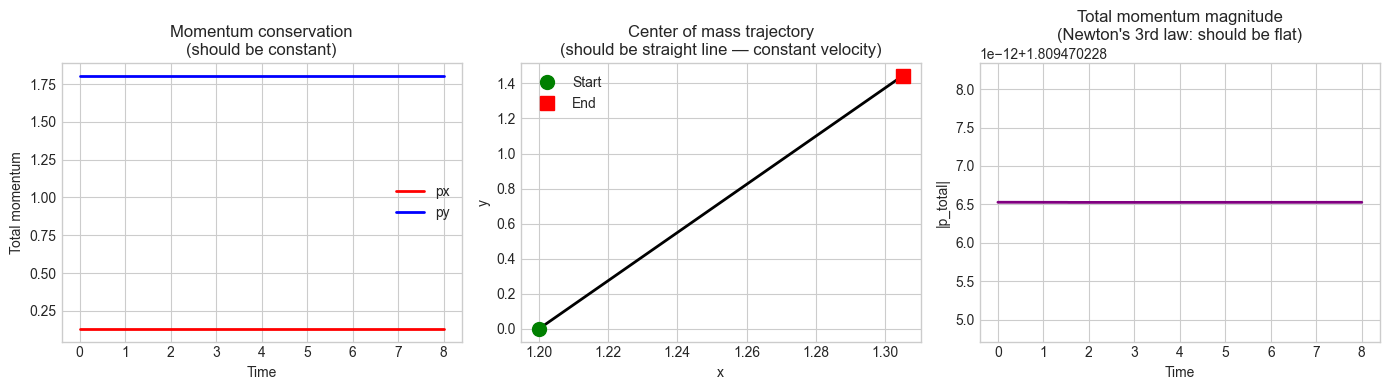

Initial total momentum: [0.131344 1.804697]
Final total momentum:   [0.131344 1.804697]
Momentum drift:         1.79e-15

COM displacement vs straight line:
  Max deviation from straight line: 2.90e-15


In [5]:
# Stage 4: Verify conservation laws — momentum and center-of-mass motion.
# In a closed system: total momentum is conserved (Newton's 3rd law guarantees this).

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Total momentum at each step: p_total = sum_i m_i * v_i
# Shape: (n_steps+1, 2)
momenta = np.einsum('i,tij->tj', masses, vel_hist)  # sum over particles

# Center of mass position
total_mass = masses.sum()
com = np.einsum('i,tij->tj', masses, pos_hist) / total_mass  # weighted average

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

t_vals = np.arange(len(momenta)) * DT

# Total momentum
axes[0].plot(t_vals, momenta[:,0], 'r-', lw=2, label='px')
axes[0].plot(t_vals, momenta[:,1], 'b-', lw=2, label='py')
axes[0].set_xlabel('Time'); axes[0].set_ylabel('Total momentum')
axes[0].set_title('Momentum conservation\n(should be constant)')
axes[0].legend()

# Center of mass trajectory
axes[1].plot(com[:,0], com[:,1], 'k-', lw=2)
axes[1].plot(com[0,0], com[0,1], 'go', markersize=10, label='Start')
axes[1].plot(com[-1,0], com[-1,1], 'rs', markersize=10, label='End')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Center of mass trajectory\n(should be straight line — constant velocity)')
axes[1].legend()

# Momentum magnitude drift
p_mag = np.linalg.norm(momenta, axis=1)
axes[2].plot(t_vals, p_mag, 'purple', lw=2)
axes[2].set_xlabel('Time'); axes[2].set_ylabel('|p_total|')
axes[2].set_title('Total momentum magnitude\n(Newton\'s 3rd law: should be flat)')

plt.tight_layout()
plt.show()

print(f"Initial total momentum: {momenta[0].round(6)}")
print(f"Final total momentum:   {momenta[-1].round(6)}")
print(f"Momentum drift:         {np.linalg.norm(momenta[-1]-momenta[0]):.2e}")
print()
print("COM displacement vs straight line:")
com_velocity = momenta[0] / total_mass  # initial COM velocity
com_predicted = com[0] + com_velocity * (np.arange(len(com)) * DT)[:, None]
com_error = np.max(np.linalg.norm(com - com_predicted, axis=1))
print(f"  Max deviation from straight line: {com_error:.2e}")

---

## 6. Results & Reflection

**What was built:**
- A fully vectorized N-body gravitational simulation
- Force computation using broadcasting — no Python loops over particle pairs
- Euler integration loop with state history tracking
- Trajectory visualization with energy decomposition (KE, PE, total)
- Conservation law verification: momentum and center-of-mass motion

**What math made it possible:**
- Vector addition (ch125): force superposition, velocity/position updates
- Norms and direction vectors (ch128–130): force magnitude and direction
- Scalar multiplication (ch126): F = ma in vector form
- Broadcasting (ch146): computing all N² force pairs without explicit loops
- NumPy einsum/indexing (ch147): efficient batch computations over particle arrays

**Extension challenges:**
1. **Symplectic integrator:** Replace Euler integration with the leapfrog (Störmer-Verlet) method, which better conserves energy. Compare energy drift between methods.
2. **Repulsive force:** Add a short-range repulsive force (Lennard-Jones potential) so particles bounce off each other rather than passing through.
3. **Collision detection:** Add elastic collision handling when two particles come within a threshold distance. Use the center-of-mass frame and dot/cross products to compute post-collision velocities.